# VCG Loss and PenaltyQAOA Tuning

This notebook reads saved results and exports figures. Error bars on mean plots show **95% confidence intervals for the mean** across constraints in Study A or COPs in Study B:

$$\bar y\;\pm\;t_{0.975,\,n-1}\frac{s}{\sqrt n},$$

where $s$ is the sample standard deviation and $n$ is the number of contributing instances. Optimizer restarts and measurement shots are not counted as independent instances. These are pointwise Student's t intervals, with no bootstrap or multiple-comparison adjustment. Intervals are omitted when fewer than two instances contribute.

The intervals approximate uncertainty in the mean for the represented problem mix. Small or skewed groups can have unreliable coverage; they do not establish that one method is better than another. Bounds are not clipped to $[0,1]$. Scatter plots, individual training histories, and dataset or state distributions show individual observations rather than means and therefore have no mean confidence intervals. Tables retain explicitly named standard-deviation columns as descriptive statistics.

Smoke results use short training runs to check the code.

In [ ]:
from pathlib import Path
import os, sys, json
candidates = [Path.cwd(), *Path.cwd().parents, Path.cwd() / "code-tuning"]
REPO = next(p for p in candidates if (p / "tuning/config.json").exists())
os.environ.setdefault("MPLCONFIGDIR", str(REPO / "tuning/.cache/matplotlib"))
sys.path.insert(0, str(REPO / "tuning"))
from analyze import read_results, status_summary, ranking, FigureWriter, figures
from IPython.display import display, Image

# Edit this path to compare a different saved run.
RESULTS_DIR = Path(os.environ.get("PCQAOA_TUNING_RESULTS", str(REPO / "tuning/results/full")))
if not (RESULTS_DIR / "run.json").exists():
    RESULTS_DIR = REPO / "tuning/results/smoke"
# Study B has its own directory so the existing Study A run stays intact.
B_RESULTS_DIR = Path(os.environ.get("PCQAOA_TUNING_B_RESULTS",
    str(REPO / "tuning/results/full-b-five-methods" if RESULTS_DIR.name == "full" else RESULTS_DIR)))
if not (B_RESULTS_DIR / "run.json").exists():
    B_RESULTS_DIR = RESULTS_DIR
data = read_results(RESULTS_DIR, B_RESULTS_DIR)
writers = {"a": FigureWriter(RESULTS_DIR / "figures", latex=True),
           "b": FigureWriter(B_RESULTS_DIR / "figures", latex=True)}

def show_section(section, study):
    writer = writers[study]
    for path in figures(data, section, writer, study=study):
        display(Image(filename=str(path), width=900))
    print("Fonts:", writer.font_status)


## Study A: VCG Loss Selection

### Progress and Dataset Composition

Rerun the next cell to refresh this study. A completed VCG task can have fidelity below 0.999.

In [ ]:
data = read_results(RESULTS_DIR, B_RESULTS_DIR)
print("Results:", RESULTS_DIR)
print(json.dumps(status_summary(RESULTS_DIR)["a"], indent=2))
instances = data["a_instances"]
if not instances.empty:
    display(instances[['id', 'support', 'family', 'feasible_count', 'feasible_fraction']])
show_section("datasets", "a")

### Loss Functions and Fidelity

Let $\mathcal F$ be the feasible set and $|\psi_\theta\rangle$ the trained state. The target is

$$|u_{\mathcal F}\rangle=\frac{1}{\sqrt{|\mathcal F|}}\sum_{x\in\mathcal F}|x\rangle.$$

The three state measurements are

$$P_{\mathcal F}=\sum_{x\in\mathcal F}|\langle x|\psi_\theta\rangle|^2,\qquad
F=|\langle u_{\mathcal F}|\psi_\theta\rangle|^2,\qquad
F_{\mathrm{cond}}=\frac{F}{P_{\mathcal F}}.$$

The code sets $F_{\mathrm{cond}}=0$ when $P_{\mathcal F}\leq10^{-12}$ to avoid division by zero.

The run compares **five loss conditions**, using three formulas:

$$\begin{aligned}
L_{\mathrm{feas}} &= 1-2P_{\mathcal F},\\
L_{\mathrm{fid}} &= 1-F,\\
L_{0.5} &= (1-P_{\mathcal F})+0.5(1-F_{\mathrm{cond}}),\\
L_1 &= (1-P_{\mathcal F})+(1-F_{\mathrm{cond}}),\\
L_2 &= (1-P_{\mathcal F})+2(1-F_{\mathrm{cond}}).
\end{aligned}$$

At each depth, retain the restart with the lowest final training loss. Stop when its fidelity reaches 0.999 or after depth 8. Return the highest-fidelity state among the retained depths. Select the loss with the highest mean returned fidelity across all 50 constraints.

Depth plots include only tasks that reached each depth. Early stopping can change which constraints contribute to those means. Rankings shown before all tasks finish are incomplete.

In [ ]:
if not data["a"].empty:
    display(ranking(data["a"], "fidelity"))
    display(data["a"][["instance_id", "condition", "fidelity", "p_feasible", "conditional_fidelity",
                       "entropy", "coverage", "min_conditional_probability", "selected_depth", "converged"]])
show_section("loss", "a")

### Example States and Optimization Histories

Each distribution title shows the constraint and training loss. Blue bars represent feasible states; rose bars represent infeasible states. The examples have low, middle and high returned fidelity.

Training histories record loss before each indicated update. Saved final metrics are calculated after the final update.

The training-history plot shows one constraint at one ma-QAOA depth, identified in the title along with the loss function. Each curve is a separate optimizer restart. Color and line style identify the restart in the legend. The thicker curve marked **Retained** is the restart with the lowest final training loss at that depth. It need not be the restart with the highest fidelity. The horizontal axis counts Adam updates; the vertical axis is the training loss, not fidelity. Only saved history points are plotted.


In [ ]:
show_section("examples", "a")

### Constraint Resource Estimates

These cells trace saved circuits without training or statevector simulation. Each VCG uses its returned depth and saved parameter layout. All five losses are shown. The component comparison uses the selected loss and compares **one VCG preparation** with **one penalty cost layer**; these are different operations, not full algorithm costs. Penalty components merge repeated Pauli words, as in shared-angle QAOA. A Grover mixer requires gadget unpreparation and repreparation in every outer QAOA layer.

The NISQ gate set is $\{R_X,R_Y,R_Z,H,\mathrm{CNOT},X,Y,Z,T,S\}$. The FTQC gate set is $\{H,T,\mathrm{CNOT},S\}$. Counts use PennyLane's decompositions. FTQC synthesis uses the installed estimator's precision configuration (recorded with each cached estimate); these are gate synthesis estimates, not physical-qubit or error-correction estimates. See the [PennyLane estimator documentation](https://docs.pennylane.ai/en/stable/code/qp_estimator.html).

`n_allocated` counts the gadget's decision register or the penalty register including slack. The estimator separately reports active algorithm wires and synthesis ancillas. Counts retain emitted zero-angle gates and do not run a global transpiler. Mean plots use the same pointwise 95% Student-$t$ intervals across constraints as the other notebook figures.

Estimates are cached per constraint. Changes to inputs, code, gate sets or PennyLane versions invalidate the affected cache. The CSV and JSON estimates are saved under this study's `resource_estimates/` directory.

Resource Rows: 600


representation      status    gate_set
gadget              complete  ftqc        250
                              nisq        250
penalty_cost_layer  complete  ftqc         50
                              nisq         50
Name: Rows, dtype: int64

total_gates  two_qubit_gates  \
gate_set condition    representation                                     
ftqc     feasibility  gadget                  5468.00           504.96   
         fidelity     gadget                 16159.88          1653.24   
         lambda_0.5   gadget                 17826.76          1825.00   
         lambda_1     gadget                 17412.64          1777.84   
         lambda_2     gadget                 18900.68          1942.36   
         unit_penalty penalty_cost_layer      3688.24           213.12   
nisq     feasibility  gadget                   623.62           504.96   
         fidelity     gadget                  1988.80          1653.24   
         lambda_0.5   gadget                  2194.54          1825.00   
         lambda_1     gadget                  2139.04          1777.84   
         lambda_2     gadget                  2333.64          1942.36   
         unit_penalty penalty_cost_layer       292.10           213.12   

                                           t_gates  n_allocated  total_wires  
gate_set condition    representation                                          
ftqc     feasibility  gadget               4957.04          6.0          6.0  
         fidelity     gadget              14500.64          6.0          6.0  
         lambda_0.5   gadget              15995.76          6.0          6.0  
         lambda_1     gadget              15628.80          6.0          6.0  
         lambda_2     gadget              16952.32          6.0          6.0  
         unit_penalty penalty_cost_layer   3475.12          9.0          9.0  
nisq     feasibility  gadget                  0.00          6.0          6.0  
         fidelity     gadget                  0.00          6.0          6.0  
         lambda_0.5   gadget                  0.00          6.0          6.0  
         lambda_1     gadget                  0.00          6.0          6.0  
         lambda_2     gadget                  0.00          6.0          6.0  
         unit_penalty penalty_cost_layer      0.00          9.0          9.0

,instance_id,condition,representation,gate_set,selected_depth,total_gates,two_qubit_gates,t_gates,n_slack,n_allocated,algo_wires,zeroed_wires,any_state_wires
0,a_4_equality_01,feasibility,gadget,nisq,1.0,33,18,0,0,4,4,0,0
1,a_4_equality_01,feasibility,gadget,ftqc,1.0,506,18,484,0,4,4,0,0
2,a_4_equality_01,fidelity,gadget,nisq,1.0,33,18,0,0,4,4,0,0
3,a_4_equality_01,fidelity,gadget,ftqc,1.0,506,18,484,0,4,4,0,0
4,a_4_equality_01,lambda_0.5,gadget,nisq,1.0,33,18,0,0,4,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,a_8_quadratic_02,lambda_1,gadget,ftqc,4.0,52448,6152,46288,0,8,8,0,0
596,a_8_quadratic_02,lambda_2,gadget,nisq,4.0,7212,6152,0,0,8,8,0,0
597,a_8_quadratic_02,lambda_2,gadget,ftqc,4.0,52448,6152,46288,0,8,8,0,0
598,a_8_quadratic_02,unit_penalty,penalty_cost_layer,nisq,NaN,1717,1360,0,5,13,13,0,0


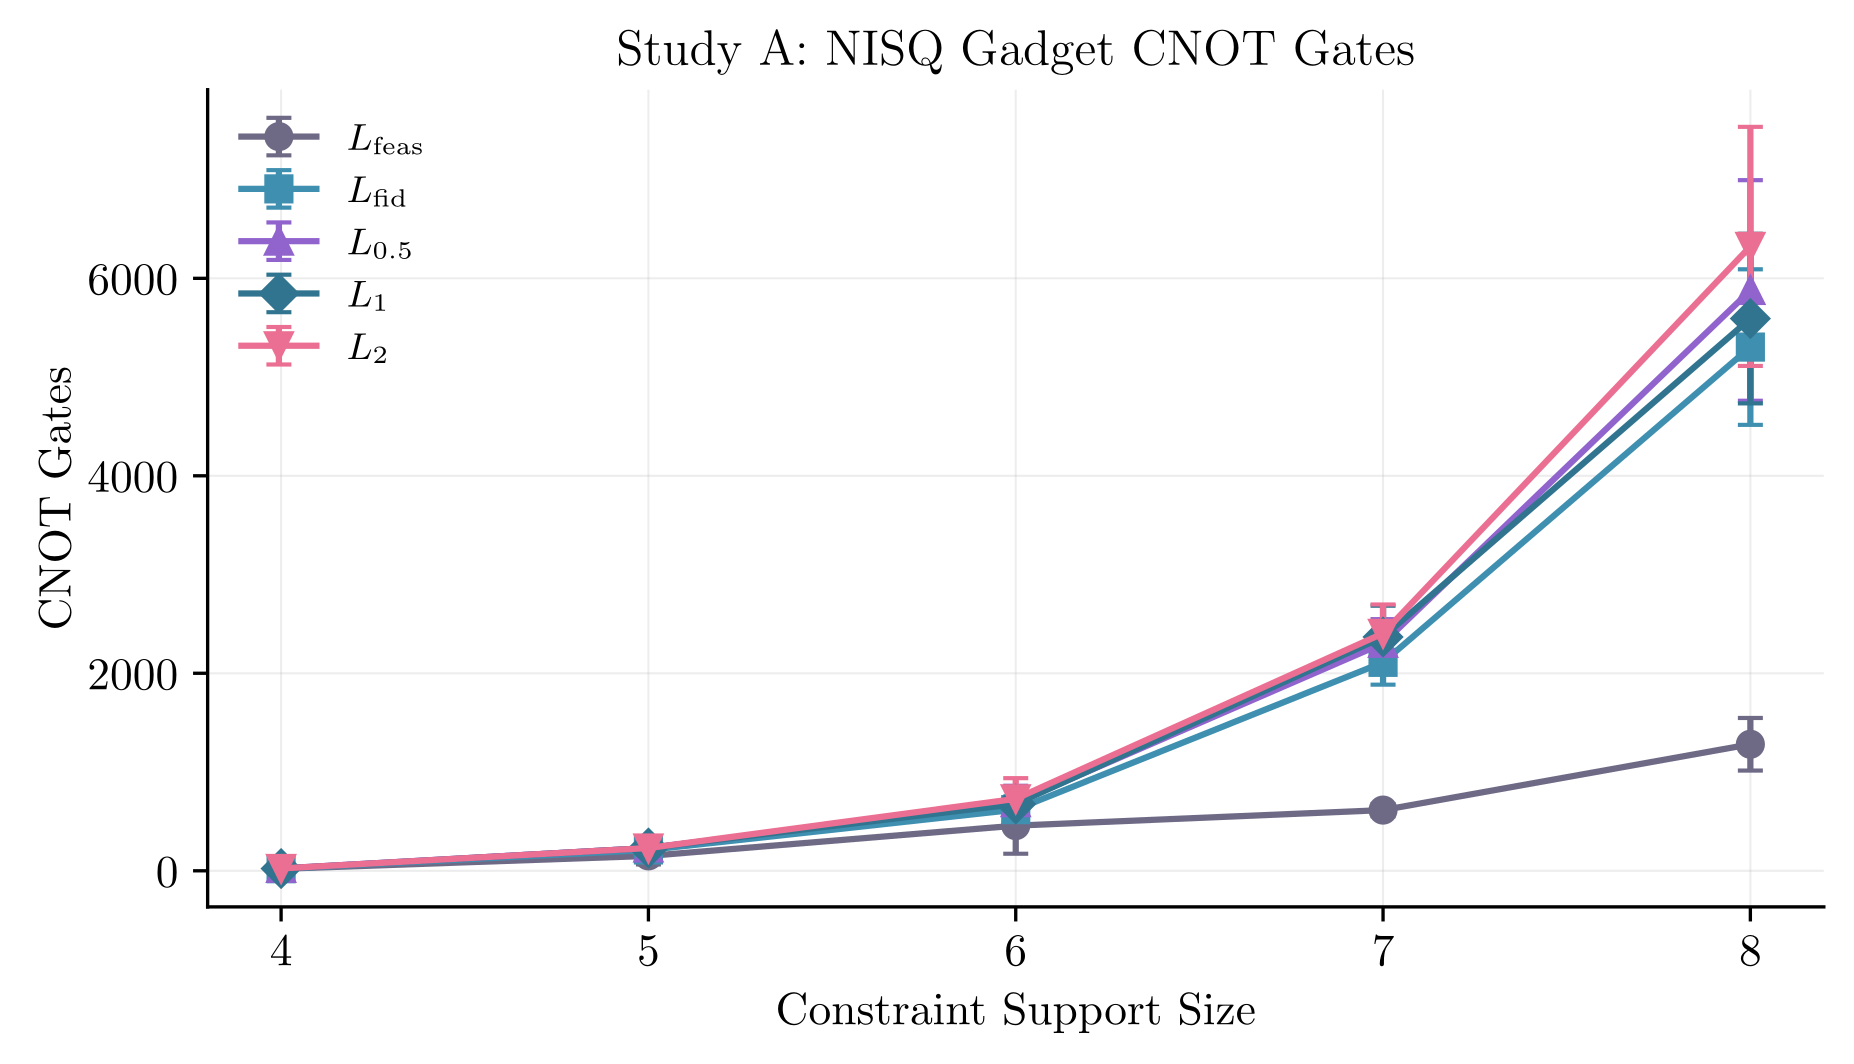

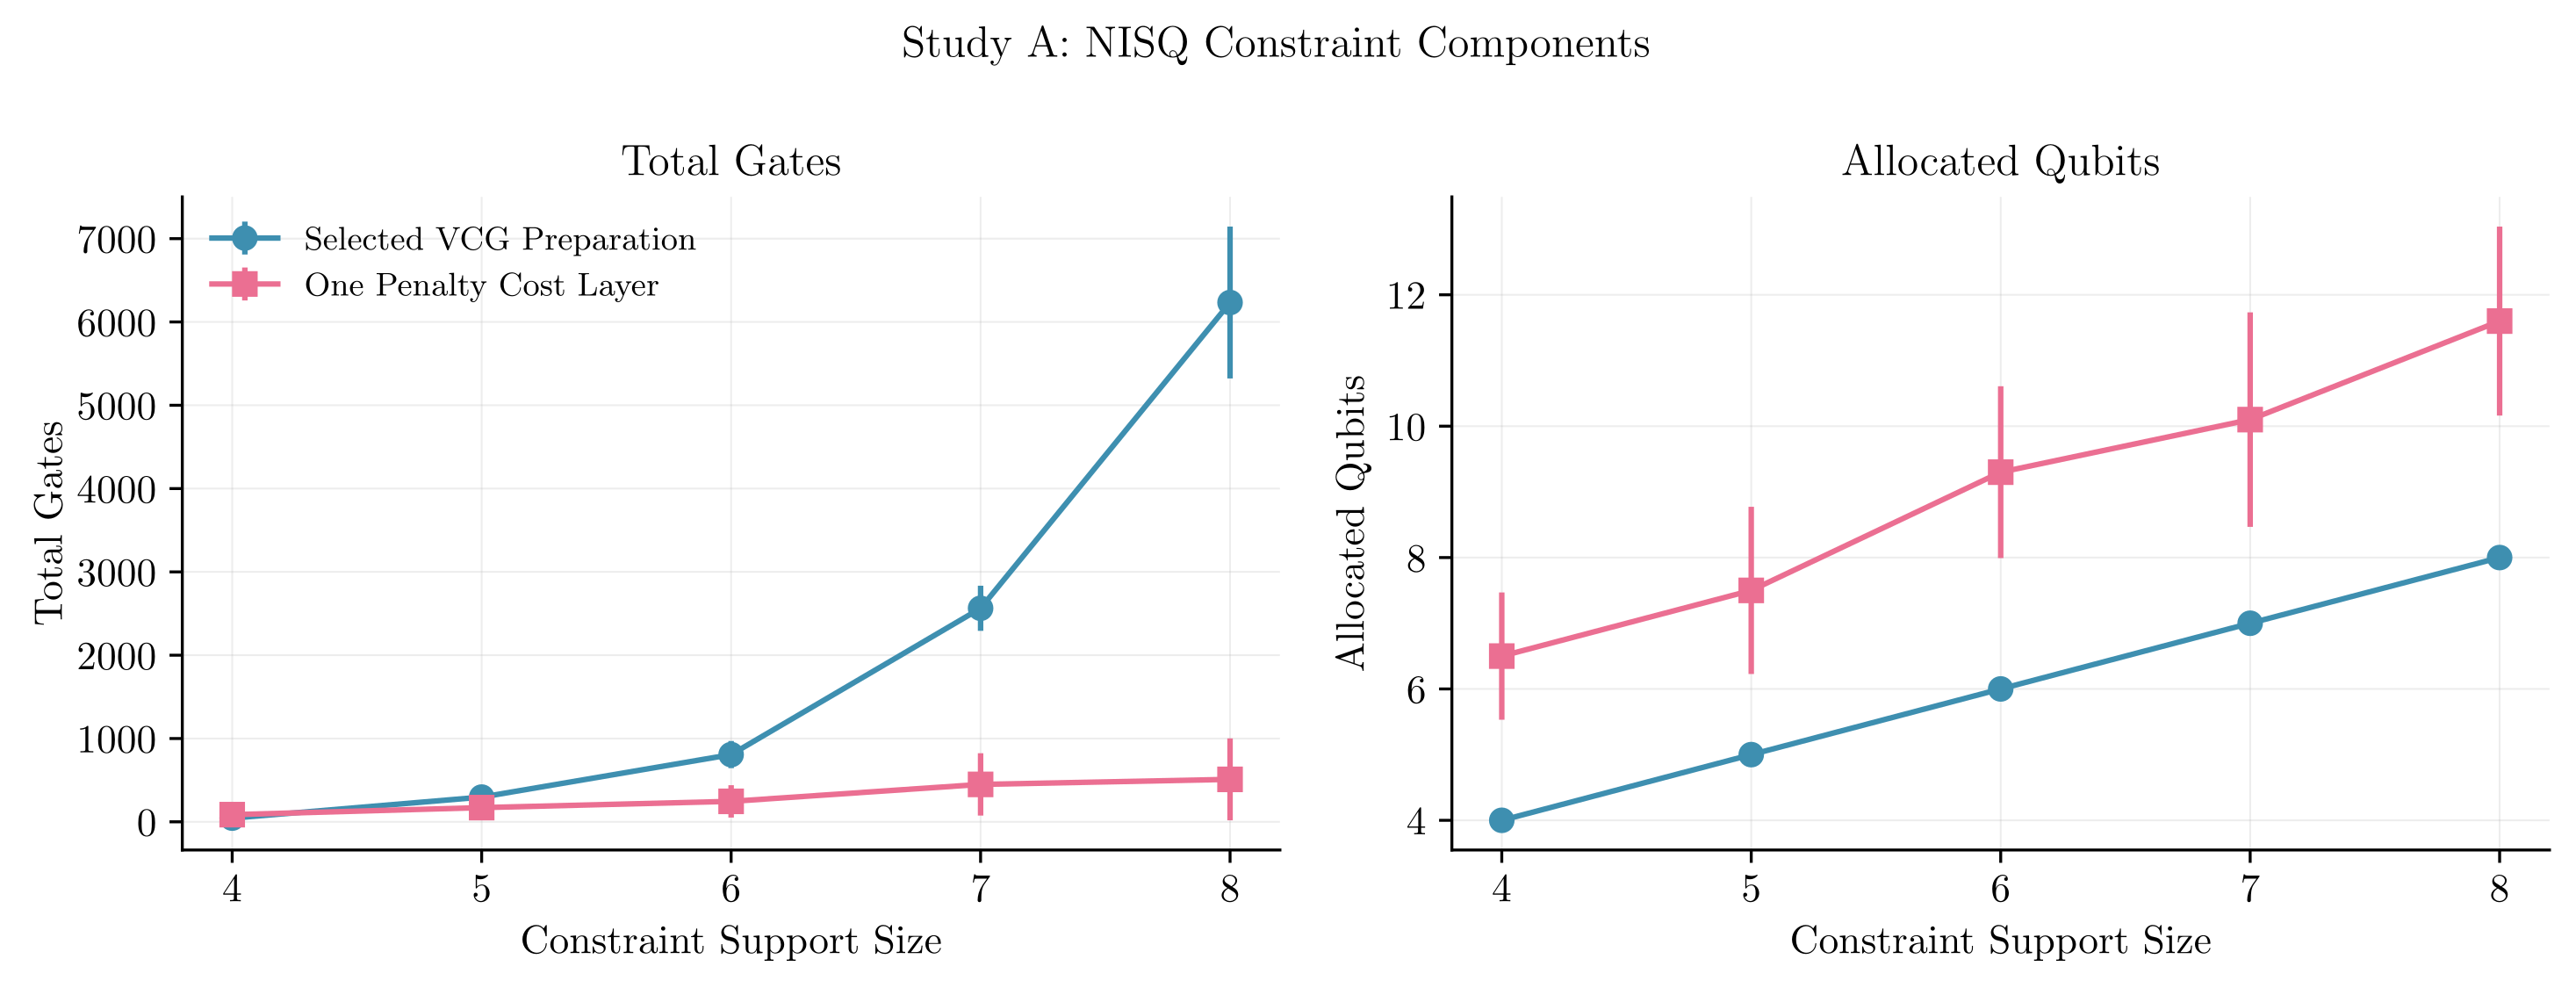

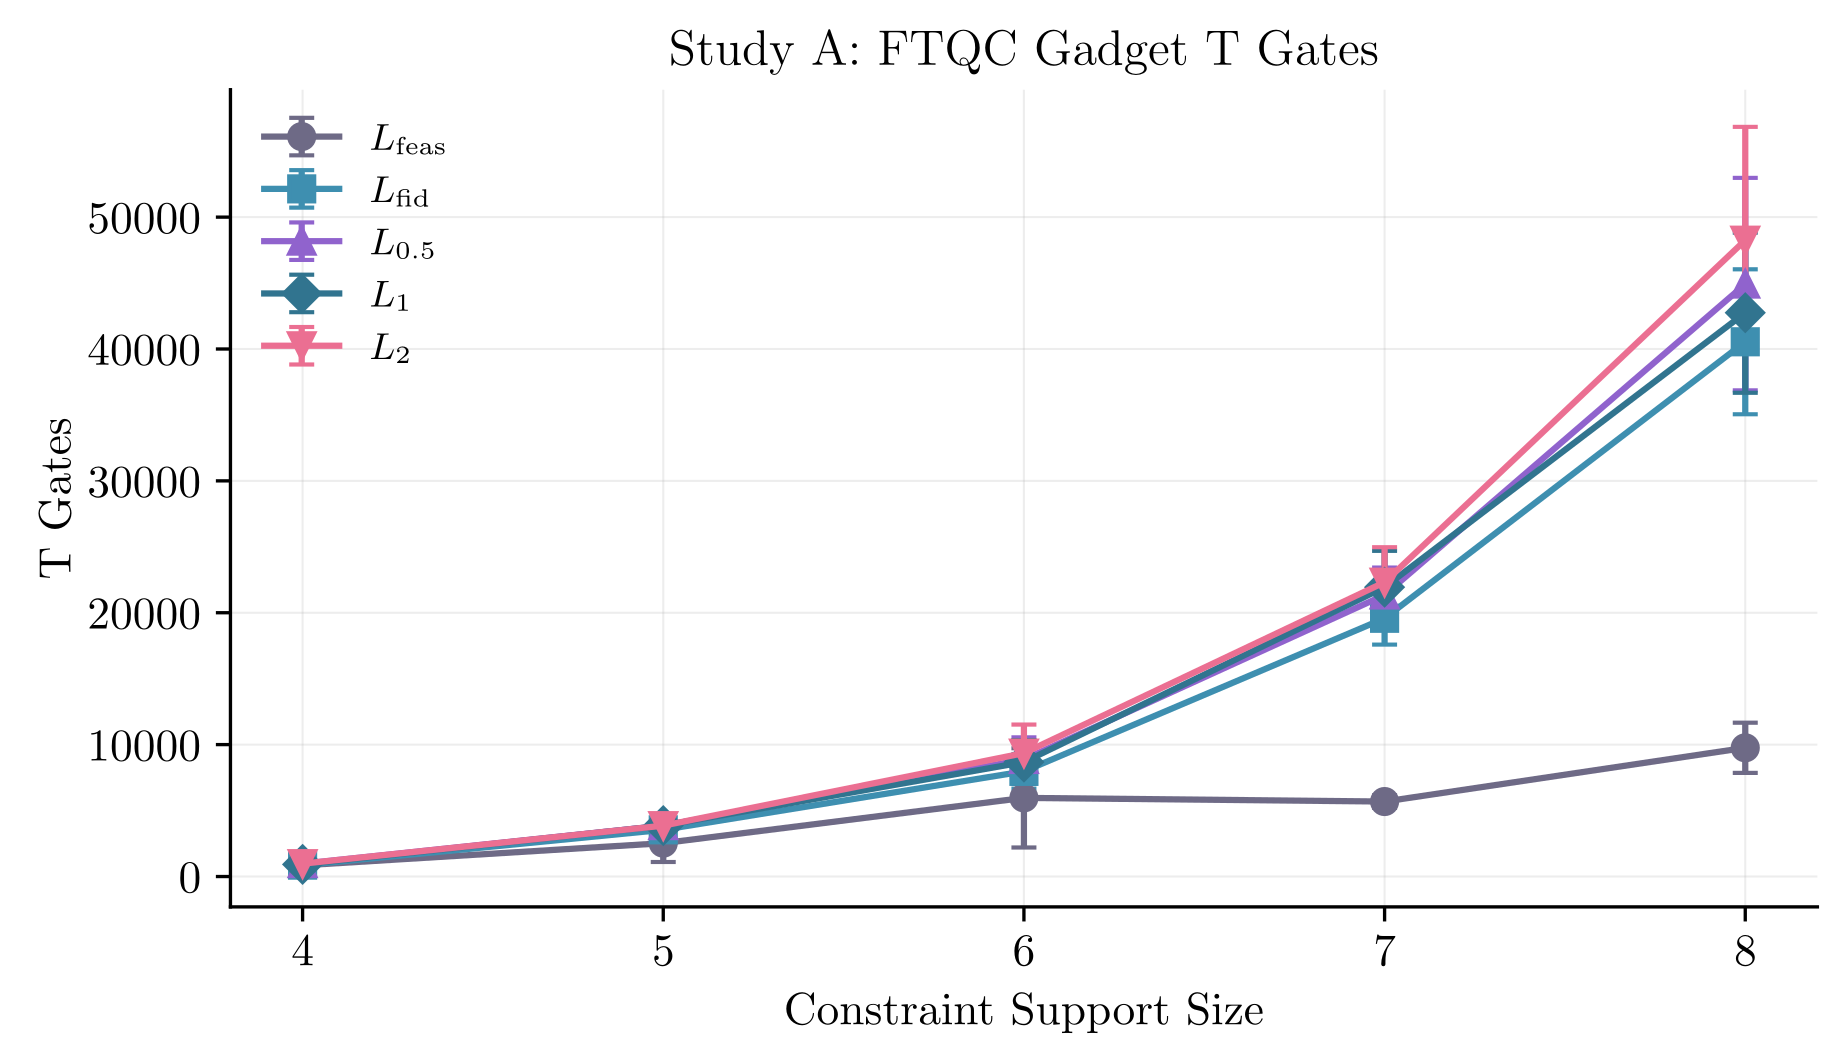

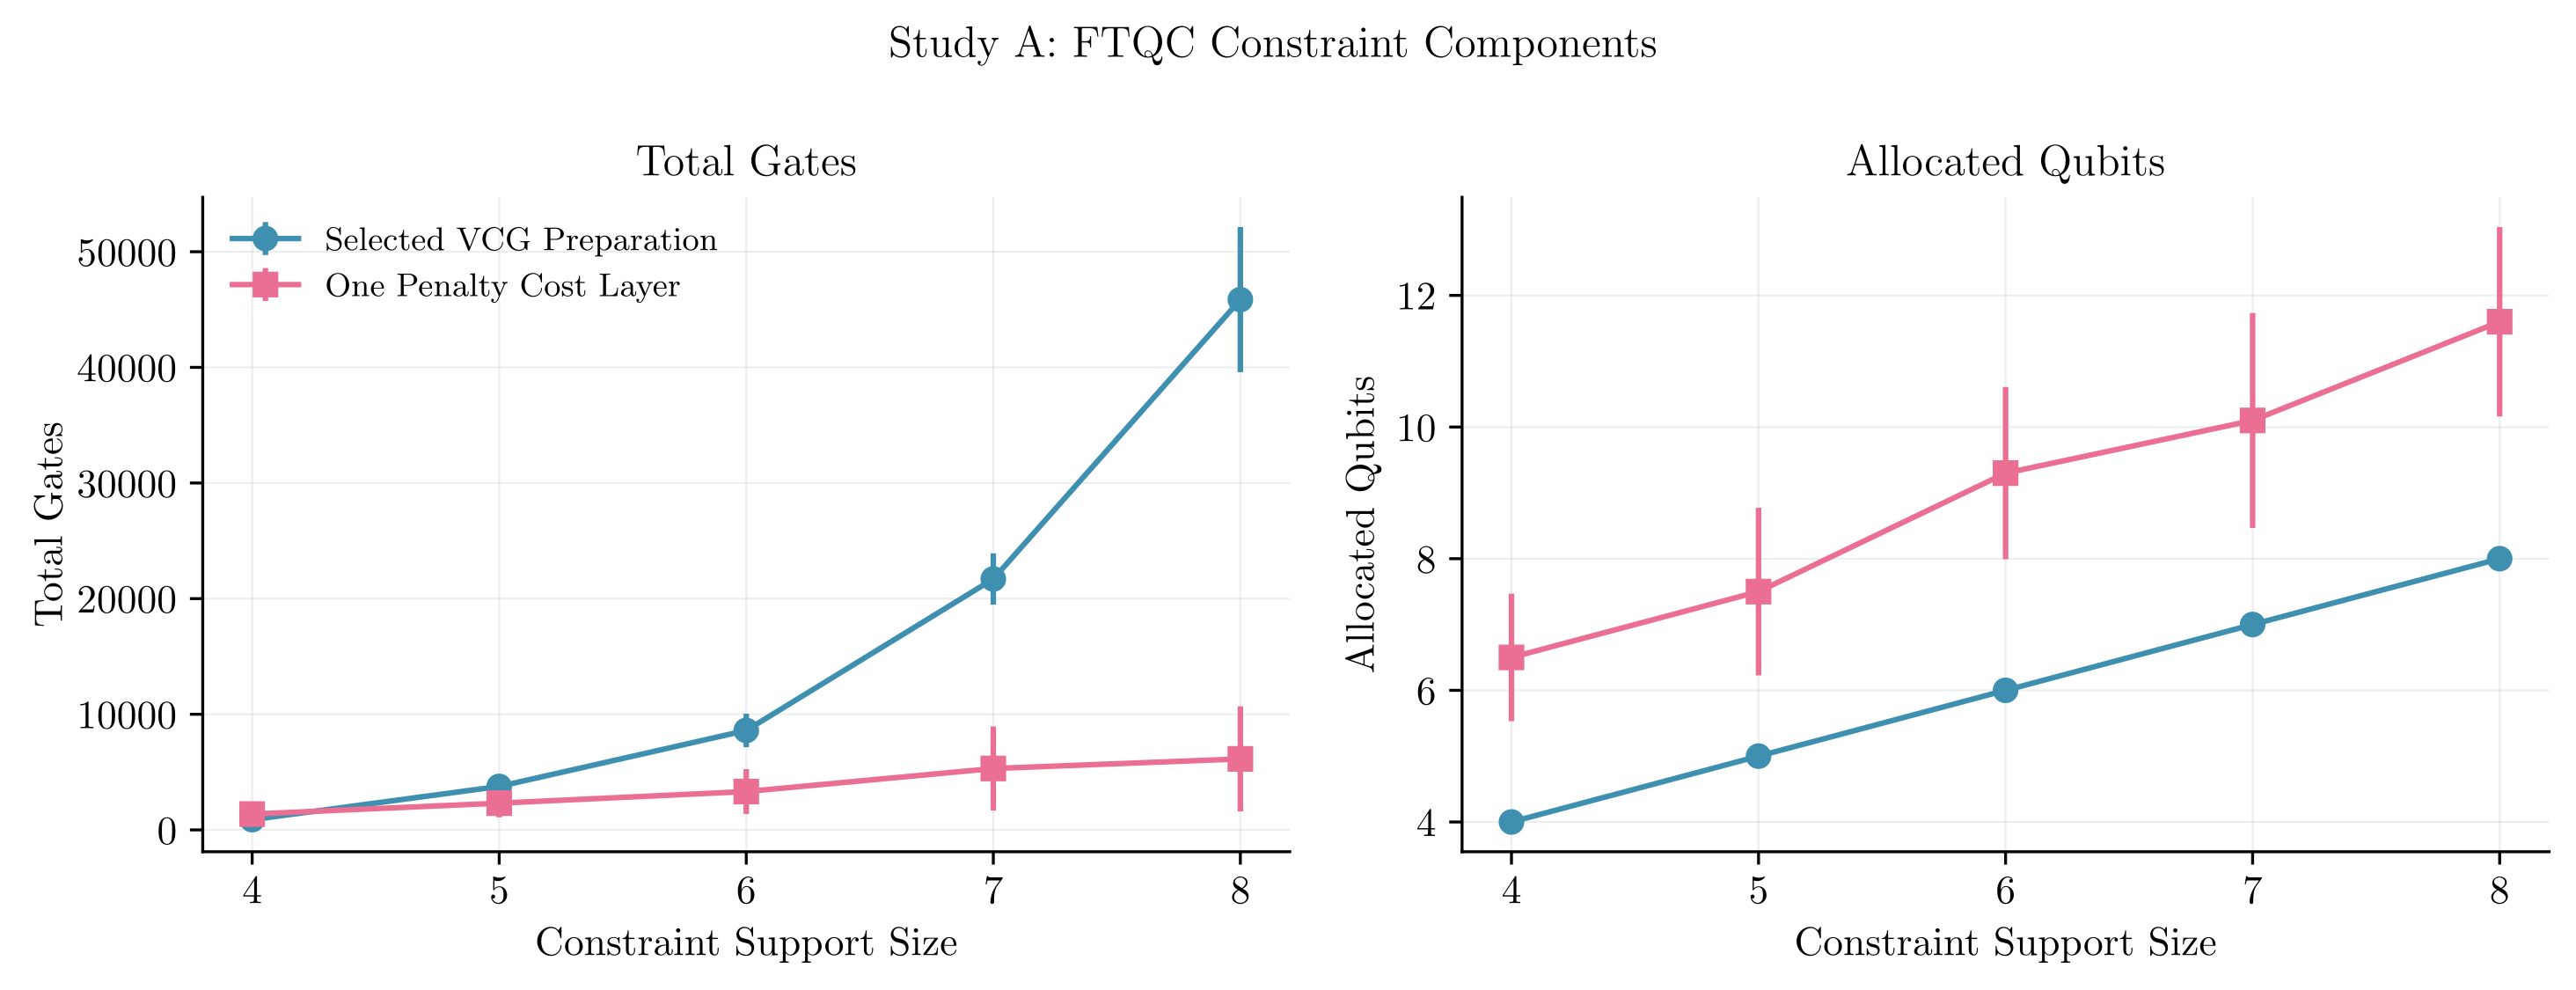

Fonts: LaTeX Computer Modern (PGF)


In [5]:
from resource_analysis import estimate_study_a, estimate_study_b, resource_figures
resource_a = estimate_study_a(RESULTS_DIR)
selection_path = RESULTS_DIR / "selected_loss.json"
selected_loss = json.loads(selection_path.read_text())["condition"] if selection_path.exists() else "fidelity"
print("Resource Rows:", len(resource_a))
if not resource_a.empty:
    display(resource_a.groupby(["representation", "status", "gate_set"]).size().rename("Rows"))
    display(resource_a.groupby(["gate_set", "condition", "representation"])[
        ["total_gates", "two_qubit_gates", "t_gates", "n_allocated", "total_wires"]].mean())
    display(resource_a[["instance_id", "condition", "representation", "gate_set",
        "selected_depth", "total_gates", "two_qubit_gates", "t_gates", "n_slack",
        "n_allocated", "algo_wires", "zeroed_wires", "any_state_wires"]])
    for path in resource_figures(resource_a, "a", writers["a"], selected_loss):
        display(Image(filename=str(path), width=900))
    print("Fonts:", writers["a"].font_status)


### Runtime

Compilation and optimizer-update times are recorded separately. Peak RSS is the largest resident memory use of the worker process.

In [ ]:
frame = data["a"]
if not frame.empty:
    display(frame.groupby("condition")[["compile_seconds", "optimize_seconds", "process_peak_rss_mb"]].agg(["mean", "std"]))

### Saved Selection and Reproducibility

The selection file is written after all tasks in this study finish.

In [ ]:
path = RESULTS_DIR / "selected_loss.json"
print(path.read_text() if path.exists() else "No final selection yet.")
print("Environment:")
print(json.dumps(data["run"]["environment"], indent=2))
print("Figure Directory:", writers["a"].directory)

## Study B: Penalty Selection

### Progress and Dataset Composition

Rerun the next cell to refresh this study. Feasible fractions count decision strings satisfying all COP constraints.

In [ ]:
data = read_results(RESULTS_DIR, B_RESULTS_DIR)
print("Results:", B_RESULTS_DIR)
print(json.dumps(status_summary(B_RESULTS_DIR)["b"], indent=2))
instances = data["b_instances"]
if not instances.empty:
    display(instances[['id', 'n_x', 'regime', 'families', 'n_structural', 'n_penalty', 'n_slack', 'feasible_fraction']])
show_section("datasets", "b")

### Penalty Methods and Optimal-Solution Probability

Write the objective with each coefficient counted once:

$$f(x)=\sum_i q_i x_i+\sum_{i<j}q_{ij}x_ix_j.$$

Here $q_i=Q_{ii}$ and $q_{ij}=Q_{ij}$ for the saved upper-triangular matrix. Set $c_{ij}=q_{\min(i,j),\max(i,j)}$ for $i\ne j$. Let $q_t$ range over all objective coefficients and define

$$L_Q=\sum_t\min(0,q_t),\qquad U_Q=\sum_t\max(0,q_t).$$

Study B compares **five fixed penalty rules**. There are no multipliers and no manuscript-reference setting:

$$\begin{aligned}
\delta_{\mathrm{range}} &= U_Q-L_Q+1,\\
\delta_{\mathrm{feasible}} &= f(\bar x)-L_Q+1,\\
\delta_{\mathrm{VL}} &= 1+\max_i\left\{q_i+\sum_{j\ne i}\max(c_{ij},0),\;-q_i-\sum_{j\ne i}\min(c_{ij},0)\right\},\\
\delta_{\mathrm{local}} &= 1+\max_i\left(|q_i|+\sum_{j\ne i}|c_{ij}|\right),\\
\delta_{\mathrm{max}} &= 1+\max_t|q_t|.
\end{aligned}$$

The feasible point $\bar x$ is the first feasible string found in a seeded random ordering of decision strings, searched without replacement. The search checks constraints only and stops immediately on success. Its seed, number of checks and elapsed time are saved. The objective is evaluated only after the point is chosen. This enumeration-based search is intended for the small calibration COPs; finding a feasible point can be expensive on larger problems.

The range and feasible-solution bounds are sufficient for the integer squared-residual encoding. Verma–Lewis, absolute local change and maximum coefficient are heuristics for these general overlapping constraints. The signed local calculation follows [Verma and Lewis (2022)](https://doi.org/10.1016/j.disopt.2020.100594); the sufficient bounds use the objective-bound reasoning discussed by [Diez García et al. (2022)](https://doi.org/10.1145/3520304.3528925).

None of these rules uses an optimum. Exact optimal solutions are calculated separately to measure performance. For the set $\mathcal X^\star$ of all optimal feasible decision strings,

$$P(\mathrm{opt})=\sum_{x\in\mathcal X^\star}P(x).$$

Slack registers are marginalized before calculating this probability. Standard QAOA runs at depths 1–5, with 10 restarts and 50 Adam steps per restart at learning rate 0.01. At each depth, retain the restart with the lowest final penalized expectation. Select the method with the highest mean sampled $P(\mathrm{opt})$ at depth 5, using 10,000 shots per COP. All five methods are eligible: **20 COPs × five methods = 100 tasks**. Exact probabilities are shown for comparison. Smoke runs use shorter budgets.

In [ ]:
if not data["b"].empty:
    display(ranking(data["b"], "p_optimal"))
    display(data["b"][["instance_id", "condition", "delta", "selectable", "depth", "p_optimal",
                       "p_feasible", "exact_p_optimal", "exact_p_feasible"]])
show_section("penalty", "b")
if not data["b_instances"].empty:
    search_columns = ["id", "feasible_point", "feasibility_search_seed",
                      "feasibility_search_attempts", "feasibility_search_seconds"]
    display(data["b_instances"].reindex(columns=search_columns))

### Constraint and Circuit Resource Estimates

Constraint-component rows show gadget preparation and one penalty cost layer for each constraint occurrence. Penalty components merge repeated Pauli words. Exact gadgets are estimated directly. A VCG absent from the supplied database is marked `missing_vcg`; it is never trained during resource estimation. Study B's constraints come from different pools, so the Study A database does not supply every VCG. Missing contributions must not be treated as zero-cost complete gadgets.

Full-circuit rows cover PenaltyQAOA at all saved depths and penalty settings. Counts include Hadamards on **all decision and slack qubits**, cost evolution and $X$ mixers. They use the merged Pauli-word topology executed during Study B training. The five penalty settings share that topology, so their counts are identical under this angle-independent estimate. Figures use one setting per COP to avoid counting the same COP five times. The merging plot compares one raw expanded layer with one executed merged layer.

For outer depth $p$, the total is $G_{\mathrm{prep}}+pG_{\mathrm{layer}}$. A full circuit includes objective terms and mixers; sums of isolated constraint components are not bounds on its total cost. No full PC-QAOA comparison is reported here. The gate sets and synthesis assumptions are the same as Study A. Mean plots use pointwise 95% intervals across COPs, with four COPs per decision size. Individual points identify disjoint and overlapping COPs.

The database path can be changed below. Cache files and resource CSVs are saved in Study B's `resource_estimates/` directory.

VCG Database: /home/ard22l/PCQAOA/code-tuning/tuning/results/full/selected_vcg_db.pkl
Resource Rows: 1200


representation      status       gate_set
full_penalty_qaoa   complete     ftqc        500
                                 nisq        500
gadget              complete     ftqc         27
                                 nisq         27
                    missing_vcg  ftqc         23
                                 nisq         23
penalty_cost_layer  complete     ftqc         50
                                 nisq         50
Name: Rows, dtype: int64

Constraint Occurrences Without a Saved VCG: 23


,instance_id,constraint,family
116,b_4_overlapping_01,1*x_0*x_0 + 1*x_0*x_3 + 3*x_0*x_1 + 2*x_0*x_2 ...,quadratic_knapsack
120,b_4_overlapping_01,5*x_0 + 4*x_2 + 1*x_1 <= 6,knapsack
124,b_4_overlapping_01,4*x_1*x_1 + 4*x_1*x_0 + 1*x_1*x_3 + 5*x_1*x_2 ...,quadratic_knapsack
178,b_4_overlapping_02,10*x_2 + 8*x_3 + 10*x_0 <= 9,knapsack
182,b_4_overlapping_02,8*x_2 + 5*x_3 + 7*x_0 + 4*x_1 <= 11,knapsack
240,b_5_disjoint_01,x_0 + x_1 >= 0,cardinality
244,b_5_disjoint_01,5*x_2*x_2 + 1*x_2*x_3 + 2*x_2*x_4 + 5*x_3*x_3 ...,quadratic_knapsack
356,b_5_overlapping_01,3*x_0*x_0 + 1*x_0*x_2 + 3*x_0*x_4 + 1*x_2*x_2 ...,quadratic_knapsack
364,b_5_overlapping_01,x_4 + x_2 + x_1 >= 1,cardinality
418,b_5_overlapping_02,1*x_1 + 6*x_4 + 9*x_0 + 8*x_3 + 9*x_2 <= 18,knapsack


total_gates  two_qubit_gates  t_gates  n_allocated
gate_set condition   depth                                                    
ftqc     feasible    1.0        3188.45            122.3   3055.8        10.35
                     2.0        6366.55            244.6   6111.6        10.35
                     3.0        9544.65            366.9   9167.4        10.35
                     4.0       12722.75            489.2  12223.2        10.35
                     5.0       15900.85            611.5  15279.0        10.35
         local       1.0        3188.45            122.3   3055.8        10.35
                     2.0        6366.55            244.6   6111.6        10.35
                     3.0        9544.65            366.9   9167.4        10.35
                     4.0       12722.75            489.2  12223.2        10.35
                     5.0       15900.85            611.5  15279.0        10.35
         maximum     1.0        3188.45            122.3   3055.8        10.35
                     2.0        6366.55            244.6   6111.6        10.35
                     3.0        9544.65            366.9   9167.4        10.35
                     4.0       12722.75            489.2  12223.2        10.35
                     5.0       15900.85            611.5  15279.0        10.35
         range       1.0        3188.45            122.3   3055.8        10.35
                     2.0        6366.55            244.6   6111.6        10.35
                     3.0        9544.65            366.9   9167.4        10.35
                     4.0       12722.75            489.2  12223.2        10.35
                     5.0       15900.85            611.5  15279.0        10.35
         verma_lewis 1.0        3188.45            122.3   3055.8        10.35
                     2.0        6366.55            244.6   6111.6        10.35
                     3.0        9544.65            366.9   9167.4        10.35
                     4.0       12722.75            489.2  12223.2        10.35
                     5.0       15900.85            611.5  15279.0        10.35
nisq     feasible    1.0         202.10            122.3      0.0        10.35
                     2.0         393.85            244.6      0.0        10.35
                     3.0         585.60            366.9      0.0        10.35
                     4.0         777.35            489.2      0.0        10.35
                     5.0         969.10            611.5      0.0        10.35
         local       1.0         202.10            122.3      0.0        10.35
                     2.0         393.85            244.6      0.0        10.35
                     3.0         585.60            366.9      0.0        10.35
                     4.0         777.35            489.2      0.0        10.35
                     5.0         969.10            611.5      0.0        10.35
         maximum     1.0         202.10            122.3      0.0        10.35
                     2.0         393.85            244.6      0.0        10.35
                     3.0         585.60            366.9      0.0        10.35
                     4.0         777.35            489.2      0.0        10.35
                     5.0         969.10            611.5      0.0        10.35
         range       1.0         202.10            122.3      0.0        10.35
                     2.0         393.85            244.6      0.0        10.35
                     3.0         585.60            366.9      0.0        10.35
                     4.0         777.35            489.2      0.0        10.35
                     5.0         969.10            611.5      0.0        10.35
         verma_lewis 1.0         202.10            122.3      0.0        10.35
                     2.0         393.85            244.6      0.0        10.35
                     3.0         585.60            366.9      0.0        10.35
                     4.0         777.35            489.2      0.0        10.35

,instance_id,condition,gate_set,depth,delta,total_gates,prep_gates,layer_gates,expanded_layer_gates,n_allocated,n_slack,algo_wires,zeroed_wires,any_state_wires
8,b_4_disjoint_01,feasible,nisq,1.0,16.0,30.0,4.0,26.0,44.0,4,0,4.0,0.0,0.0
9,b_4_disjoint_01,feasible,nisq,2.0,16.0,56.0,4.0,26.0,44.0,4,0,4.0,0.0,0.0
10,b_4_disjoint_01,feasible,nisq,3.0,16.0,82.0,4.0,26.0,44.0,4,0,4.0,0.0,0.0
11,b_4_disjoint_01,feasible,nisq,4.0,16.0,108.0,4.0,26.0,44.0,4,0,4.0,0.0,0.0
12,b_4_disjoint_01,feasible,nisq,5.0,16.0,134.0,4.0,26.0,44.0,4,0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,b_8_overlapping_02,verma_lewis,ftqc,1.0,27.0,3278.0,12.0,3266.0,8050.0,12,4,12.0,0.0,0.0
1196,b_8_overlapping_02,verma_lewis,ftqc,2.0,27.0,6544.0,12.0,3266.0,8050.0,12,4,12.0,0.0,0.0
1197,b_8_overlapping_02,verma_lewis,ftqc,3.0,27.0,9810.0,12.0,3266.0,8050.0,12,4,12.0,0.0,0.0
1198,b_8_overlapping_02,verma_lewis,ftqc,4.0,27.0,13076.0,12.0,3266.0,8050.0,12,4,12.0,0.0,0.0


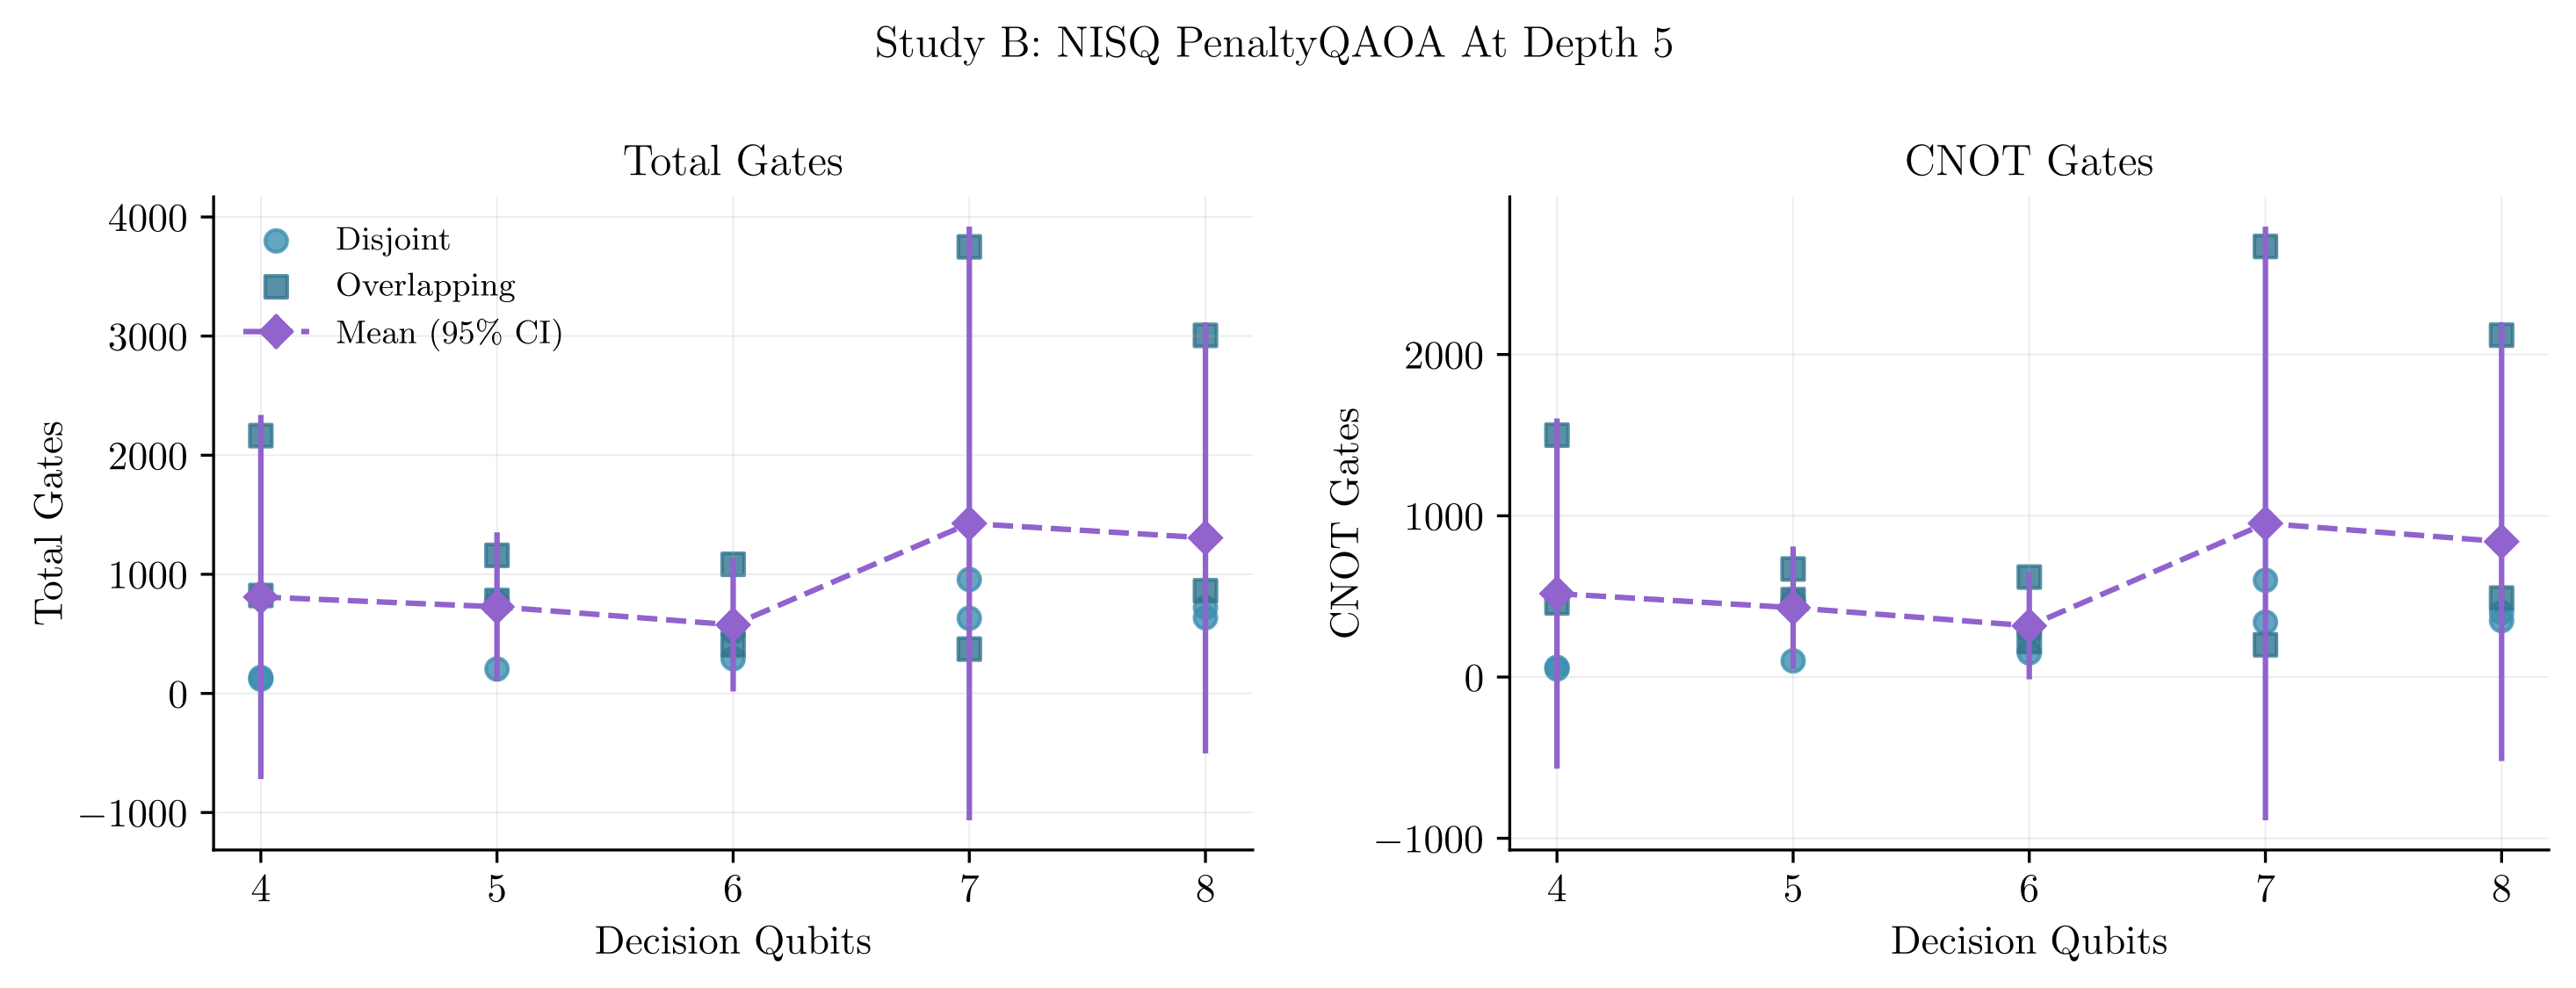

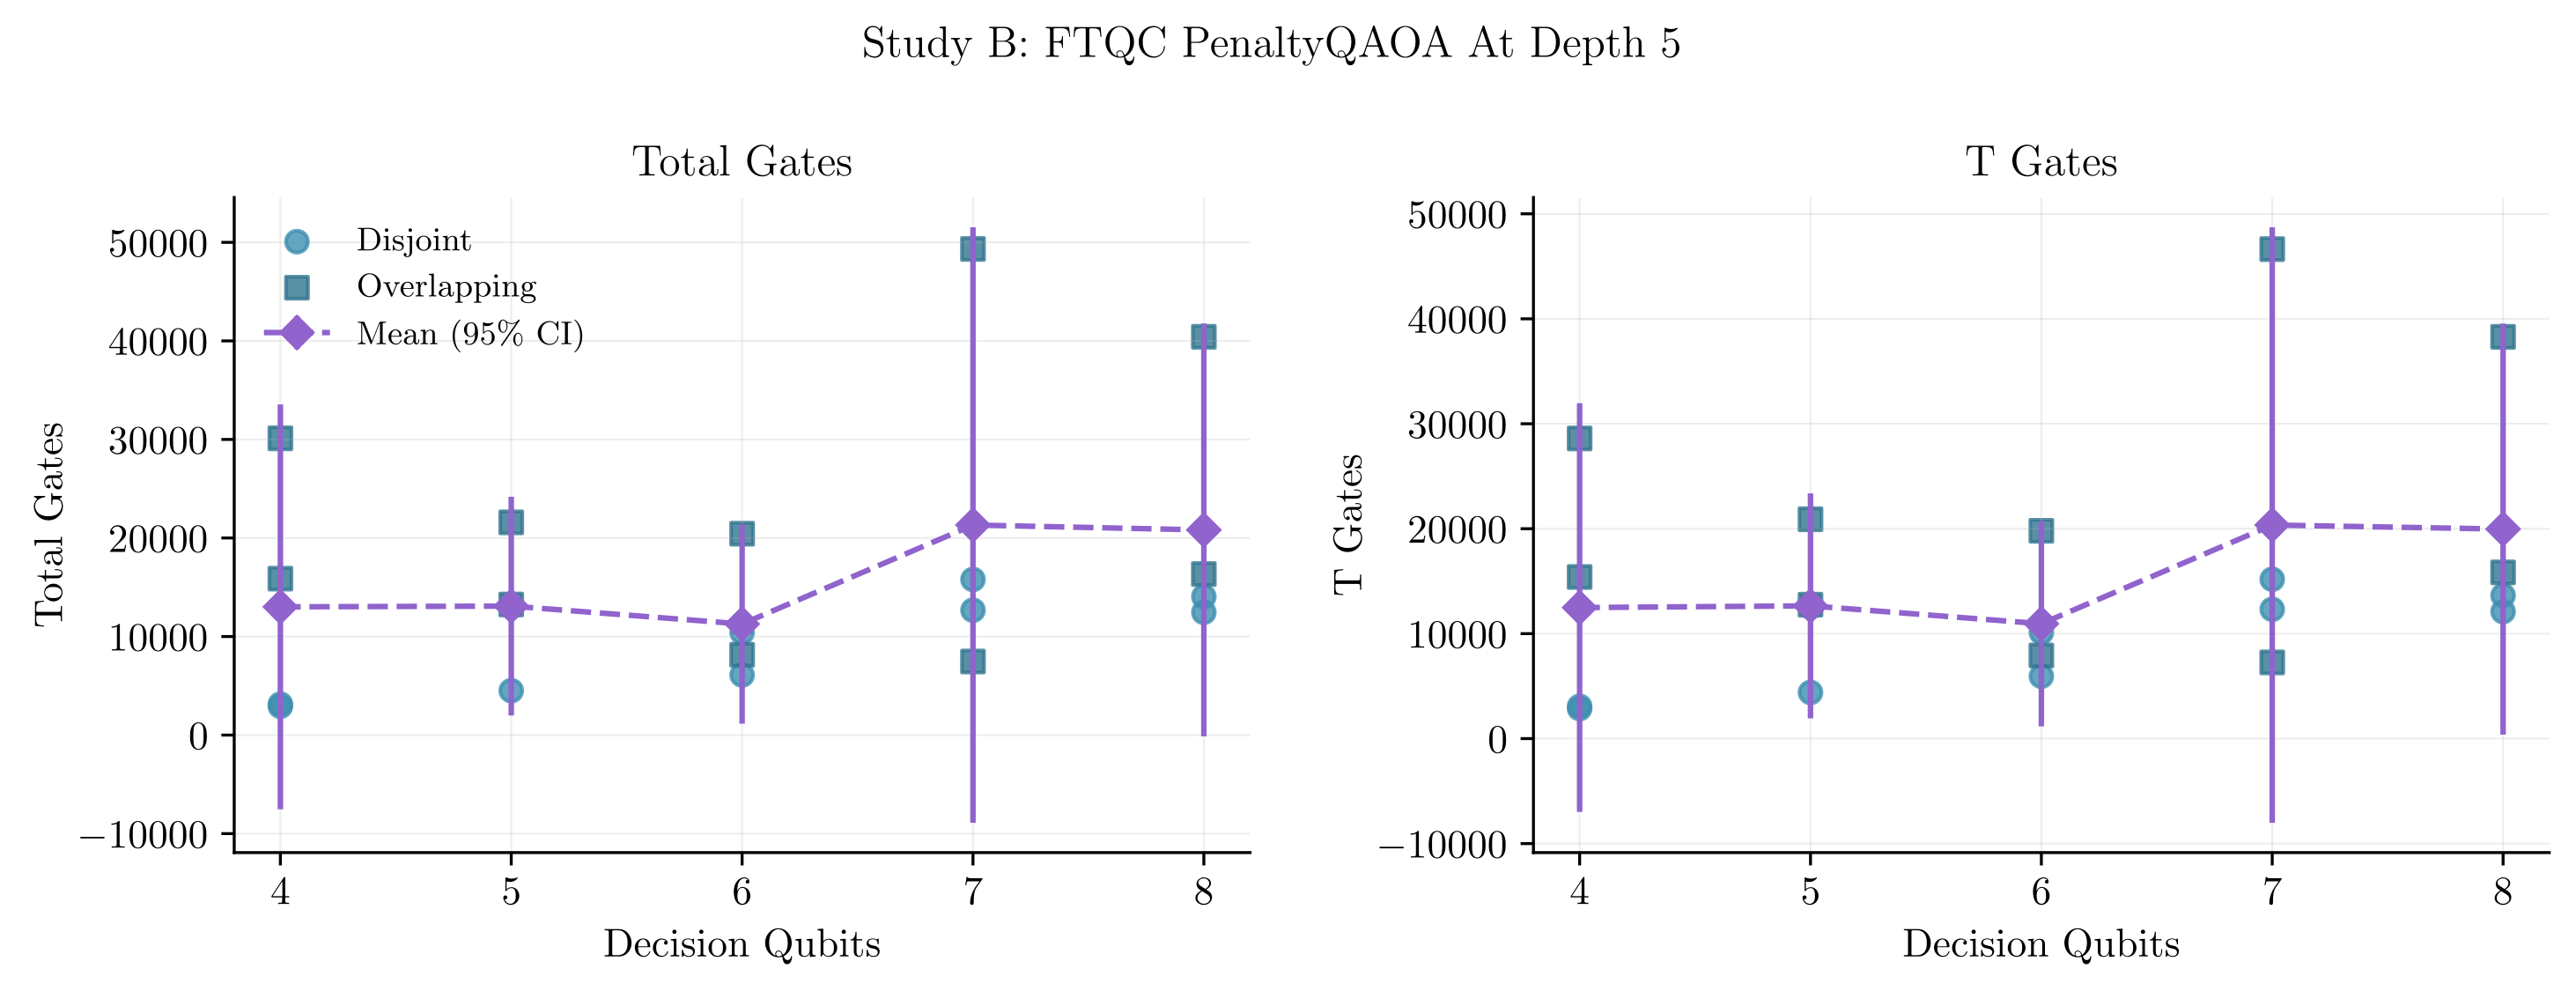

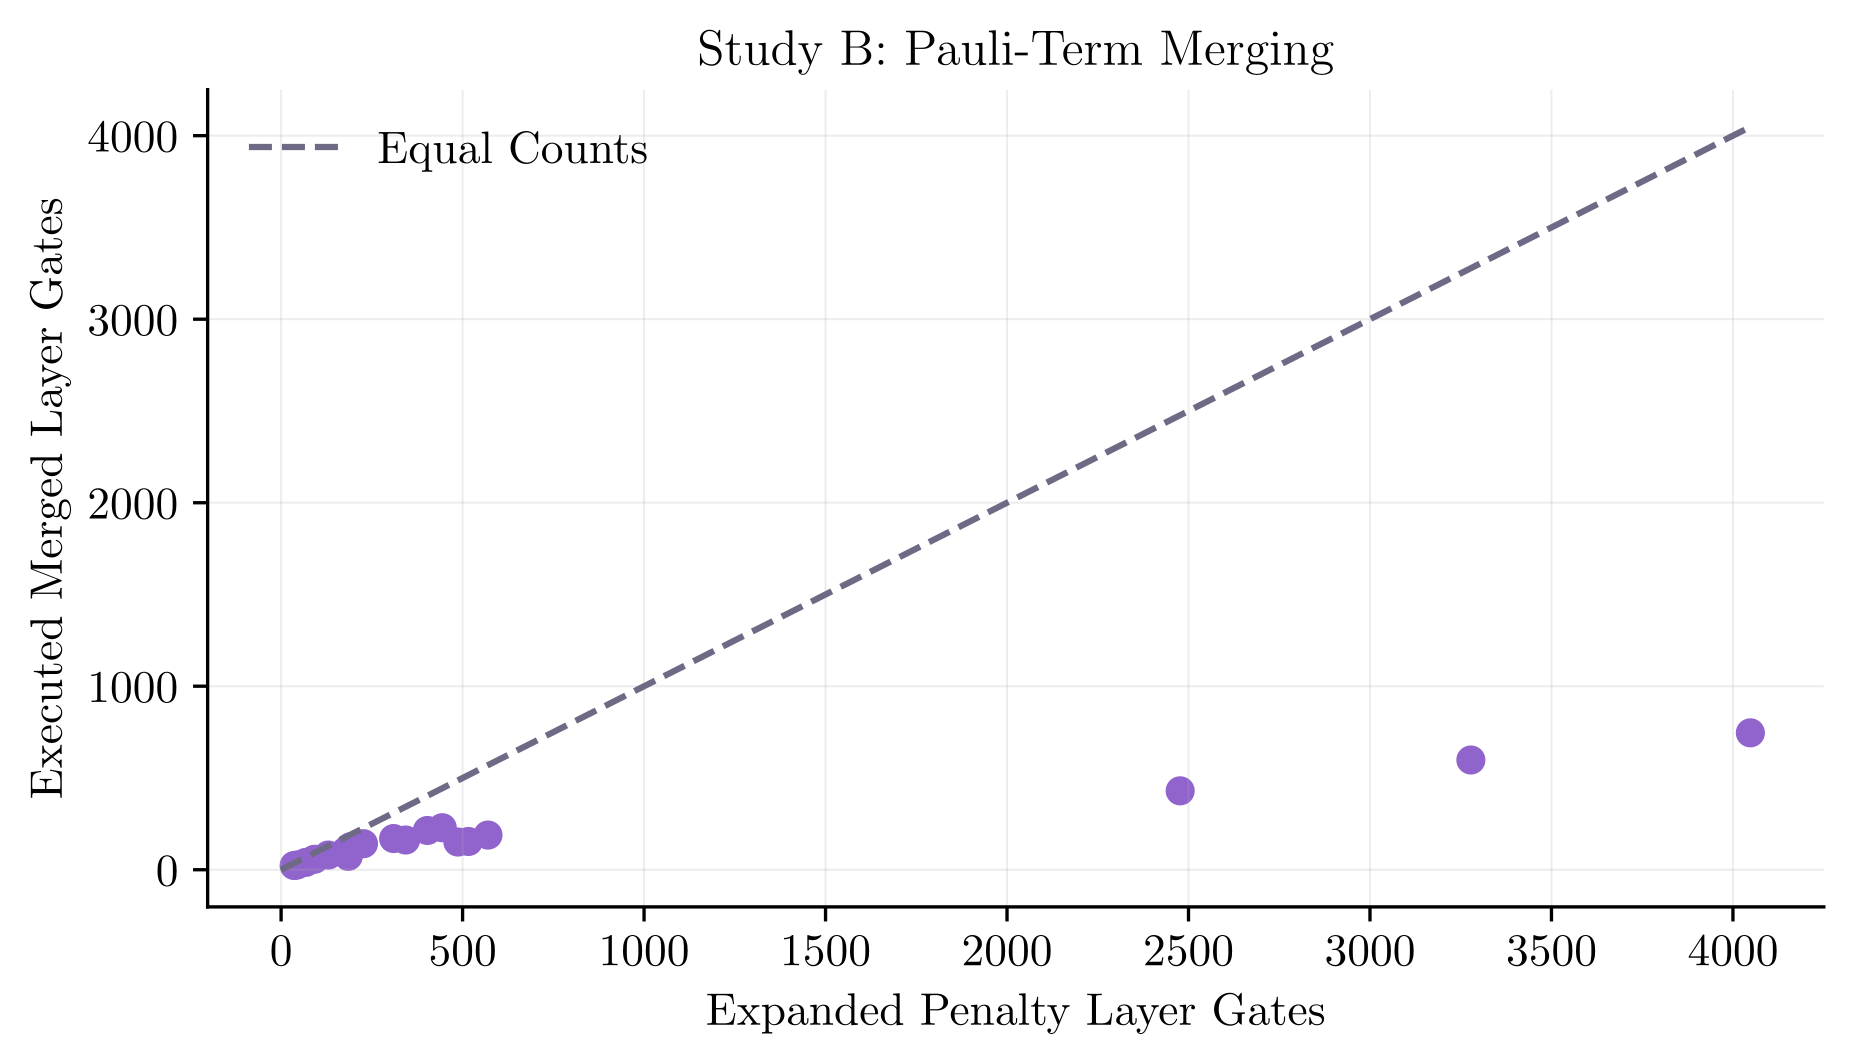

Fonts: LaTeX Computer Modern (PGF)


In [10]:
VCG_DB_PATH = RESULTS_DIR / "selected_vcg_db.pkl"
if not VCG_DB_PATH.exists():
    VCG_DB_PATH = REPO / "tuning/artifacts/selected_vcg_db.pkl"
resource_b = estimate_study_b(B_RESULTS_DIR, VCG_DB_PATH)
print("VCG Database:", VCG_DB_PATH)
print("Resource Rows:", len(resource_b))
if not resource_b.empty:
    display(resource_b.groupby(["representation", "status", "gate_set"]).size().rename("Rows"))
    missing = resource_b[resource_b.status == "missing_vcg"]
    if not missing.empty:
        print("Constraint Occurrences Without a Saved VCG:",
              len(missing[["instance_id", "constraint_index"]].drop_duplicates()))
        display(missing[["instance_id", "constraint", "family"]].drop_duplicates())
    circuits = resource_b[resource_b.representation == "full_penalty_qaoa"]
    display(circuits.groupby(["gate_set", "condition", "depth"])[
        ["total_gates", "two_qubit_gates", "t_gates", "n_allocated"]].mean())
    display(circuits[["instance_id", "condition", "gate_set", "depth", "delta",
        "total_gates", "prep_gates", "layer_gates", "expanded_layer_gates",
        "n_allocated", "n_slack", "algo_wires", "zeroed_wires", "any_state_wires"]])
    for path in resource_figures(resource_b, "b", writers["b"]):
        display(Image(filename=str(path), width=900))
    print("Fonts:", writers["b"].font_status)


### Qubits and Runtime

PC-QAOA slack counts come from the constraint partition; Study B runs only PenaltyQAOA.

Compilation and optimizer-update times are recorded separately. Peak RSS is the largest resident memory use of the worker process.

In [ ]:
show_section("resources", "b")
frame = data["b"]
if not frame.empty:
    display(frame.groupby("condition")[["compile_seconds", "optimize_seconds", "process_peak_rss_mb"]].agg(["mean", "std"]))

### Saved Selection and Reproducibility

The selection file is written after all tasks in this study finish.

In [ ]:
path = B_RESULTS_DIR / "selected_penalty.json"
print(path.read_text() if path.exists() else "No final selection yet.")
print("Environment:")
print(json.dumps(data.get("b_run", data["run"])["environment"], indent=2))
print("Figure Directory:", writers["b"].directory)

## Figure Exports

Figures are saved in each study’s own `figures/` directory as PDF and 300-dpi PNG files. Rendering uses LaTeX Computer Modern when available, with Matplotlib Computer Modern math and DejaVu Serif as the fallback. Each directory records its font choice in `font_status.json`.